# Report 1

In this test I realize a neural network that estimates a density describes by a generator of samples.

In particular, let $\mathcal{F}$ an absolutely continuous probability distribution defined in $\mathbb{R}^n$

In particular I use a distribution with density:

$$
    \hat{f}(x) \propto f(x) = \exp\left[-2V(\left\|x\right\|)\right] \quad \text{with} \quad V(r) = (r^2-1)^2
$$

I'm going to use the Rejection Sampling method to emulate the distribition $\mathcal{F}$.

This method requires another absolutely continuous probability distribution $\mathcal{G}$ with density $\hat{g}$ such that:

$$
    \exists M \left[M\hat{g} \geq \hat{f} \quad \text{a.s.}\right]
$$

The method gets a sample $Y\sim\hat{g}$ and accepts it if, taking a sample $U\sim\mathcal{U}\left[0,1\right]$, holds $MU\hat{g}(Y)\leq\hat{f}(Y)$.

The final set of samples follows the distribution $\mathcal{F}$ indeed, given a measurable set $\text{B}$, holds:

$$
    \mathbb{P}_{Y\sim\mathcal{G}}\left[Y\in\text{B} \middle| Y\text{ is sampled}\right] = \frac{\mathbb{P}_{Y\sim\mathcal{G}}\left[Y\in\text{B}, MU\hat{g}(Y)\leq\hat{f}(Y)\right]}{\mathbb{P}_{Y\sim\mathcal{G}}\left[MU\hat{g}(Y)\leq\hat{f}(Y)\right]} = \frac{\int_\text{B}dy\hat{g}(y)\int_0^1du\frac{\hat{f}(y)}{M\hat{g}(y)}}{\int dy\hat{g}(y)\int_0^1du\frac{\hat{f}(y)}{M\hat{g}(y)}} = \int_\text{B} dy\hat{f}(y) = \mathbb{P}_{X\sim\mathcal{F}}\left[X\in\text{B}\right]
$$

The efficiency of this method is defined by $\mathbb{P}_{Y\sim\mathcal{G}}\left[Y\text{ is sampled}\right] = 1/M$. So it is advised a low value $M$.

I propose the density $g(x)\propto\exp\left[-\frac{1}{2}\frac{\left\|x\right\|^2}{\sigma^2}\right]$ with $\sigma^2=\frac{1+\sqrt{2}}{4}$

Using the estimation $f(x)\leq \exp\left[\frac{1}{2\sigma^2}+\frac{1}{32\sigma^4}\right]g(x)=\exp\left[\frac{2\sqrt{2}-1}{2}\right]g(x)$, I propose an efficiency:
$$
    M = \exp\left[\frac{2\sqrt{2}-1}{2}\right] \frac{\left\|g\right\|}{\left\|f\right\|} = \exp\left[\frac{2\sqrt{2}-1}{2}\right] \frac{2\pi \sigma^2}{2\pi\int_0^\infty r\exp(-2V(r))dr}\approx 2.45877073914
$$


In [18]:
import torch
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from typing import Callable
from torch.distributions import MultivariateNormal
from matplotlib.colors import hsv_to_rgb
import numpy as np

In [19]:
# definition of the generator
# with rejection sampling

def V(r: torch.Tensor) -> torch.Tensor:
    # r: (n_samples,)
    return (r**2-1)**2
def objective_density(x: torch.Tensor) -> torch.Tensor:
    # x: (n_samples, n_dim) or (n_dim,)
    return (-2*V(torch.norm(x, dim=-1))).exp()  # (n_samples,)

class RejectionSampler:
    def __init__(
        self,
        objective_density: Callable[[torch.Tensor], torch.Tensor],
        proposal_sampler: Callable[[int, torch.device, torch.dtype], torch.Tensor],
        proposal_density: Callable[[torch.Tensor], torch.Tensor],
        M: float
    ):
        self.objective_density = objective_density
        self.proposal_sampler = proposal_sampler
        self.proposal_density = proposal_density
        self.M = M  # scaling constant

    def sample(self, n_samples, device, dtype) -> torch.Tensor:
        # n_samples: number of samples to generate
        remaining = n_samples  # oversample to improve efficiency
        samples = self.proposal_sampler(remaining, device, dtype)
        u = torch.rand(remaining) * self.M * self.proposal_density(samples)
        samples = samples[u <= self.objective_density(samples)]
        last_size = samples.shape[0]
        remaining = n_samples
        coef = 1.2  # oversampling coefficient
        while samples.shape[0] < n_samples:
            coef = remaining / last_size if last_size > 0 else coef
            remaining = int((n_samples - samples.shape[0]) * coef)
            other_samples = self.proposal_sampler(remaining, device, dtype)
            u = torch.rand(remaining) * self.M * self.proposal_density(other_samples)
            other_samples = other_samples[u <= self.objective_density(other_samples)]
            samples = torch.cat([samples, other_samples], dim=0)
            last_size = other_samples.shape[0]
        return samples[:n_samples]

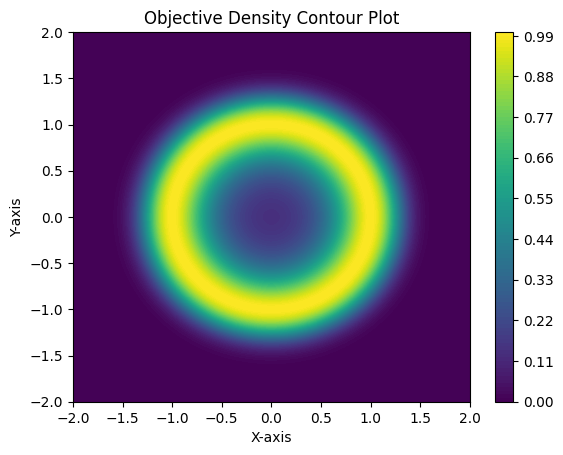

In [20]:
# see the density in 3D plot
X, Y = torch.meshgrid(torch.linspace(-2, 2, 200), torch.linspace(-2, 2, 200), indexing='ij')
Z = objective_density(torch.stack([X.flatten(), Y.flatten()], dim=1)).reshape(X.shape)
plt.contourf(X.numpy(), Y.numpy(), Z.numpy(), levels=100)
plt.colorbar()
plt.title("Objective Density Contour Plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

In [21]:
# define proposal distribution

variance = (1+2**0.5)/4

def proposal_sampler(n_samples: int, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    # n_samples: number of samples to generate
    return MultivariateNormal(
        loc=torch.zeros(2, device=device, dtype=dtype),
        covariance_matrix=variance*torch.eye(2, device=device, dtype=dtype)
    ).sample((n_samples,))

def proposal_density(x: torch.Tensor) -> torch.Tensor:
    # x: (n_samples, n_dim)
    return torch.exp(-0.5 * x.pow(2).sum(dim=1) / variance)

generator = RejectionSampler(
    objective_density=objective_density,
    proposal_sampler=proposal_sampler,
    proposal_density=proposal_density,
    M=torch.tensor((2*2**0.5-1)/2).exp()
)

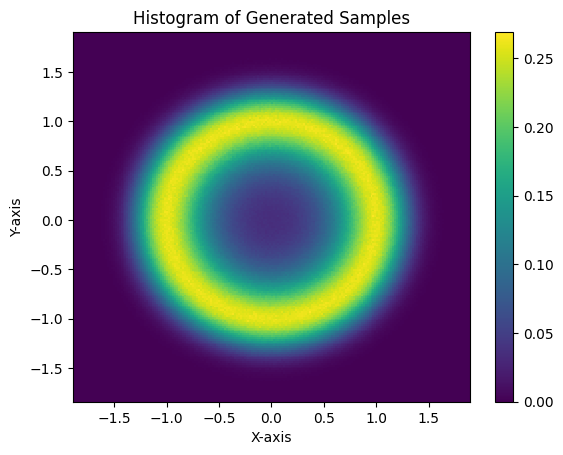

In [22]:
# example of generated samples
samples = generator.sample(int(1e8), device='cpu', dtype=torch.float32)

# show histogram of samples and scatter plot
plt.hist2d(samples[:, 0].numpy(), samples[:, 1].numpy(), bins=200, density=True, cmap='viridis')
plt.colorbar()
plt.title("Histogram of Generated Samples")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

del samples

## Fokker Planck equation

The SDE with this stady state is:

$$
    dX_t = (-\nabla_{X_t}V(\left\|X_t\right\|)+RX_t)dt + dW_t = f(X_t)dt+\sigma(X_t)dW_t \quad \text{with} \quad R=\left[\left[0,1\right],\left[-1,0\right]\right]
$$

The respective Fokker Planck equation is:
$$
    u_t(x) = - \nabla_x\cdot u(x)f(x) + \nabla_x^2 \cdot \Sigma(x) u(x) = \left[u,\nabla_x u, \frac12\nabla_x^2 u\right]\cdot\left[\nabla_x^2\cdot\Sigma(x)-\nabla_x\cdot f(x), \nabla_x\cdot\Sigma(x)-f(x),\Sigma(x)\right]=\mathcal{L}u(x) \quad \text{with} \quad \Sigma(x)=\sigma(x)^T\sigma(x)
$$

In this case:

$\nabla_x^2\cdot\Sigma(x)-\nabla_x\cdot f(x) = -\nabla_x\cdot f(x) = -\nabla_x\cdot\left(-\nabla_{x}V(\left\|x\right\|)+Rx\right)=V''\left(\left\|x\right\|\right) + (n-1)V'\left(\left\|x\right\|\right)/\left\|x\right\|+\text{Tr}\left(R\right)=O_{r\to\infty}(r^2)$

$\nabla_x\cdot\Sigma(x)-f(x) = \nabla_{x}V(\left\|x\right\|)-Rx = V'(\left\|x\right\|)\frac{x}{\left\|x\right\|}-Rx=O_{r\to\infty}(r^2)$

$\Sigma(x)=1$

Final time:  1.0


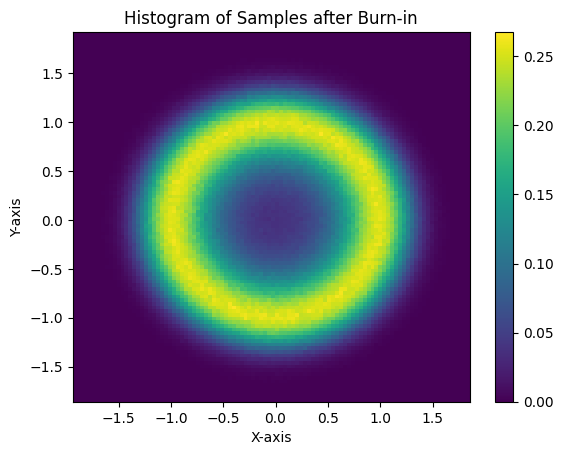

In [23]:
# monte carlo simulation
from phd_laboratory import sde
from phd_laboratory.sde import euler_maruyama

R = torch.tensor([[0.0,1.0],[-1.0,0.0]], dtype=torch.float32, device='cuda')

# Define drift, diffusion, and initial state functions
def sde_drift(X: torch.Tensor, _t):
    R = torch.tensor([[0.0,1.0],[-1.0,0.0]], dtype=X.dtype, device=X.device)
    return - 4 * (torch.norm(X, dim=-1, keepdim=True)**2-1) * X + torch.einsum('ij, sj -> si', R, X)
def sde_diffusion(X: torch.Tensor, _t):
    return torch.tile(torch.eye(X.shape[1], dtype=X.dtype, device=X.device), (X.shape[0], 1, 1))
def initial_state(n_samples: int,):
    return torch.rand((n_samples, 2), dtype=torch.float32, device='cuda')*4-2

SDEModel = sde.Model(
    sde_drift,
    sde_diffusion,
    initial_state,
    initial_time=0.0,
    n_dim=2
)
dt_schedule = torch.ones(int(1/0.01), dtype=torch.float64, device='cuda') * 0.01
print("Final time: ", dt_schedule.sum().item())
euler_maruyama = euler_maruyama.EulerMaruyama(SDEModel, dt_schedule)
X = euler_maruyama.get_end(n_samples=int(1e7))  # shape: (n_samples, 2)
plt.hist2d(X[:, 0].cpu().numpy(), X[:, 1].cpu().numpy(), bins=100, density=True, cmap='viridis')
plt.colorbar()
plt.title("Histogram of Samples after Burn-in")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()
del X

## The problem
I want estimate the function $u$ with the only information:
- $\mathcal{L}u\equiv0$
- $\int u = 1$

I define a neural network $\tilde{u}_\theta(x) = \varphi(x)\exp\left(\tilde{w}_\theta(x)\right)$ where:
- $\varphi(x)$ is an integrable function. Spoiler: with a particular decay, for example $O_{r\to\infty}\left(e^{-r^2}\right)$
- $\nabla_x\tilde{w}_\theta, \nabla^2_x\tilde{w}_\theta$ are bounded functions. Spoiler: with a common neural network design it is verified.

**Theorem**

Let $u,h$ two measurable functions.

If there exists $g$ such that $h\leq g(u)$ and there exists $R>0$ such that $0<\left\|g(u|_{u<R})\right\|<\infty$ then:

Let $M_R=\left\{u < R\right\}$ and $h_R(x)=\mathbb{1}_{M_R}(x)g(u(x))$

$h\leq g(u)\implies\left\|h\right\|\leq\frac{\left\|h_R\right\|}{\left\|uh_R\right\|}\left\|uh\right\|$ where $R$ is such that $0<\left\|h_R\right\|<\infty$

Properties of $h_R$:
- $R\geq Q\implies h_R\geq h_Q$
- $h_0\equiv0$ and $h_\infty\equiv g(u)$
- $h > h_R \implies u\geq R$ and $h< h_R\implies u<R$
- $\int uh - \int uh_R = \int u\left(h-h_R\right) = \int_{h > h_R} u\left(h-h_R\right) - \int_{h_R > h} u\left(h_R-h\right)\geq R\int_{h > h_R} \left(h-h_R\right) - R\int_{h_R > h} \left(h_R-h\right)=2R\int h-h_R$. So $\left\|h\right\|\geq\left\|h_R\right\|\implies\left\|uh\right\|\geq\left\|uh_R\right\|$

Let $R$ be such that $0<\left\|g(u|_{u<R})\right\|<\infty$ and given $h_n$ a sequence such that $\left\|uh_n\right\|\to0$ and $\left\|h_n\right\|\to L>0$, then $\left\|h_n\frac{\left\|h_R\right\|}{\left\|h_n\right\|}\right\|=\left\|h_R\right\|$.

This implies that $\left\|uh_R\right\|\leq\left\|uh_n\frac{\left\|h_R\right\|}{\left\|h_n\right\|}\right\|=\left\|uh_n\right\|\frac{\left\|h_R\right\|}{\left\|h_n\right\|}\to0$. So $\left\|uh_R\right\|=0$ and so $h_R\equiv0$, but $0<\left\|g(u|_{u<R})\right\|=\left\|h_R\right\|$

So it implies that $\lim_{\left\|uh\right\|\to0}\left\|h\right\|=0$ with $h\leq g(u)$

Finally:
$$
    \left\|h\right\|\leq C\left\|uh\right\| \iff \frac{\left\|h_R\right\|}{C}\leq\left\|u\left\|h_R\right\|\frac{h}{\left\|h\right\|}\right\|
$$
I know that $\left\|h\right\|\geq\left\|h_R\right\|\implies\left\|uh\right\|\geq\left\|uh_R\right\|$, so I choose $\frac{\left\|h_R\right\|}{C}=\left\|uh_R\right\|$.

### The loss function

If I want a property like $\int \mathcal{L}\tilde{u}_\theta(x)dx=\left\|\mathcal{L}\tilde{u}_\theta\right\|$ but I have a dataloader that follows some distribution with density $u$. So in this case $\mathcal{L}\tilde{u}_\theta$ is $h$ (of the theorem) and $u$ is $u$ (of the theorem). So in order to control $\left\|\mathcal{L}\tilde{u}_\theta\right\|$ I have to find a function $g$ such that:
- $\forall\theta\left(\mathcal{L}\tilde{u}_\theta\leq g(u)\right)$
- there exists $R>0$ such that $0<\left\|g(u|_{u<R})\right\|<\infty$

About the first condition, I have to assume that the Lipschitz coefficient of $\tilde{u}$ is bounded. For this finality, I can use a $L_2$ regularisation.

With this setup, the problem is about the limit of the density $\tilde{u}$, by replacement:
$$
    \mathcal{L}\left(\varphi\text{SoftPlus}\tilde{f}_\theta\right)(x) = \left[\tilde{u}_\theta,\nabla_x \tilde{u}_\theta, \frac12\nabla_x^2 \tilde{u}_\theta\right]\cdot\left[\nabla_x^2\cdot\Sigma(x)-\nabla_x\cdot f, \nabla_x\cdot\Sigma(x)-f,\Sigma(x)\right]
$$
So I compute:
$$
    \nabla_x \tilde{u}_\theta =\nabla_x\varphi\tilde{w}_\theta = \tilde{w}_\theta\left(\nabla_x\varphi\right) + \varphi\left(\nabla_x\tilde{w}_\theta\right)
$$
$$
    \nabla^2_x \tilde{u}_\theta = \left(\nabla_x\tilde{w}_\theta\right)\left(\nabla_x\varphi\right)^T + \tilde{w}_\theta\left(\nabla^2_x\varphi\right) + \left(\nabla_x\varphi\right)\left(\nabla_x\tilde{w}_\theta\right)^T+\varphi\left(\nabla^2_x\tilde{w}_\theta\right)
$$
Using the boundaries on $\tilde{w}_\theta$, in order to control the limit behaviour of $\tilde{u}$, I impose $\varphi(x)=r^\alpha\exp(-\beta r^\gamma)$ with $\gamma\geq1, \beta>0$. So:
- $\varphi(x)=O_{r\to\infty}\left(r^\alpha\exp(-\beta r^\gamma)\right)$
- $\nabla_x\varphi(x)=O_{r\to\infty}\left(r^{\alpha+\gamma-1}\exp(-\beta r^\gamma)\right)$
- $\nabla^2_x\varphi(x)=O_{r\to\infty}\left(r^{\alpha+2\gamma-2}\exp(-\beta r^\gamma)\right)$

With this definition I have:
$$
    \tilde{u}_\theta = \varphi\tilde{w}_\theta = O_{r\to\infty}(r^{\alpha+1}\exp(-\beta r^\gamma))
$$
$$
    \nabla_x\tilde{u}_\theta = \tilde{w}_\theta\left(\nabla_x\varphi\right) + \varphi\left(\nabla_x\tilde{w}_\theta\right) = O_{r\to\infty}(r^{\alpha+\gamma}\exp(-\beta r^\gamma))
$$
$$
    \nabla^2_x\tilde{u}_\theta = \left(\nabla_x\tilde{w}_\theta\right)\left(\nabla_x\varphi\right)^T + \tilde{w}_\theta\left(\nabla^2_x\varphi\right) + \left(\nabla_x\varphi\right)\left(\nabla_x\tilde{w}_\theta\right)^T+\varphi\left(\nabla^2_x\tilde{w}_\theta\right) = O_{r\to\infty}(r^{\alpha+2\gamma-1}\exp(-\beta r^\gamma))
$$
I can estimate $\alpha,\beta,\gamma$ using the theoretical knowledge of the problem, in this way $\mathcal{L}\tilde{u}_\theta=O_{r\to\infty}\left(r^A\exp\left(-Br^C\right)\right)$ for some $A,B,C$

If the limit behaviour is under control, then I have a good definition of $g$. But I don't forget that there must be a $L_2$ regularisation.

In this case $ \left[\nabla_x^2\cdot\Sigma(x)-\nabla_x\cdot f(x), \nabla_x\cdot\Sigma(x)-f(x),\Sigma(x)\right] = O_{r\to\infty}(r^2) $, if I choose $\varphi(x)=\exp\left(-\left\|x\right\|^{2}\right)$, then $\mathcal{L}\tilde{u}_\theta = O_{r\to\infty}\left(r^4\exp\left(-r^2\right)\right)$


In this case, I want to compute the MSE loss of $\mathcal{L}\tilde{u}_\theta$.

I observe that: $\partial_{\theta}\left(\mathcal{L}\tilde{u}_\theta\right)(x)=\left(\mathcal{L}\partial_{\theta}\tilde{u}_\theta\right)(x)$

Fixed $x$, my function is: $f_x:\theta\mapsto\left(\mathcal{L}\tilde{u}_\theta\right)(x)$ and its derivative is: $\partial_\theta f_x: \theta \to \left(\mathcal{L}\partial_\theta\tilde{u}_\theta\right)(x)$



In [24]:
# definition of the neural network
from phd_laboratory import neuralnet

class NeuralNet(neuralnet.NNTemplate):

    def __init__(self):
        super(NeuralNet, self).__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Sequential(
                torch.nn.Linear(2, 128),
                torch.nn.SiLU(),
            ),
            torch.nn.Sequential(
                torch.nn.Linear(128, 128),
                torch.nn.SiLU(),
            ),
            torch.nn.Sequential(
                torch.nn.Linear(128, 128),
                torch.nn.SiLU(),
            ),
            torch.nn.Sequential(
                torch.nn.Linear(128, 128),
                torch.nn.SiLU(),
            ),
            torch.nn.Sequential(
                torch.nn.Linear(128, 1),
                torch.nn.Softplus(beta=4),
            ),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        input_ndim_flag = x.ndim == 1
        if input_ndim_flag:
            x = x.unsqueeze(0)  # (1, n_dim)
        # x has shape (n_samples, n_dim)
        score: torch.Tensor = self.net(x).squeeze(1)  # (n_samples,)
        reference: torch.Tensor = torch.exp(-0.5*torch.sum(x**2, dim=-1)/2)  # (n_samples,)
        solution = (score+1)*reference  # (n_samples,)  (this function is integrable with mass almost 1)
        if input_ndim_flag:
            return solution.squeeze(0)  # ()
        else:
            return solution  # (n_samples,)

In [25]:
# definition of the loss
from phd_laboratory.fokker_planck import gaussian
from phd_laboratory.neuralnet.templates import Loss

class TrainLoss(Loss):
    def __init__(self):
        super(Loss, self).__init__()
        # define the fokker planck model
        self.FKmodel = gaussian.Gaussian(
            potential=lambda r2: (r2 - 1)**2,
            rotational_matrix=lambda x: torch.stack([
                torch.stack([torch.zeros(x.shape[0]), torch.ones(x.shape[0])], dim=-1),
                torch.stack([-torch.ones(x.shape[0]), torch.zeros(x.shape[0])], dim=-1),
            ], dim=-2),
            sigma=1.0,
            d_U=lambda r2: 2.0 * (r2 - 1), d2_U=lambda r2: 2.0 * torch.ones_like(r2),
        )

    def __call__(self, NNmodel: NeuralNet, batch: tuple[torch.Tensor]) -> torch.Tensor:
        # batch: (inputs, labels)
        # regularization
        regularization = torch.tensor(0.0, device=batch[0].device, dtype=batch[0].dtype)
        for layer in NNmodel.net:
            L2 = torch.mean(layer[0].weight**2)
            regularization += L2
        regularization /= len(NNmodel.net)
        # Lu loss computation
        Lu = torch.zeros(batch[0].shape[0], device=batch[0].device, dtype=batch[0].dtype)
        if batch[0].shape[0]>0:
            Lu = self.FKmodel.u_t(lambda y,_: NNmodel(y), batch[0], 0.0)
        Lu = (Lu**2).mean()
        # normalization of the loss
        y = NNmodel(batch[0])
        Lu = Lu / (y.mean()**2)
        return Lu #+ 1e-5 * regularization

    def eval(self, NNmodel: NeuralNet, batch: tuple[torch.Tensor]) -> dict[str, float]:
        # regularization
        regularization = torch.tensor(0.0, device=batch[0].device, dtype=batch[0].dtype)
        for layer in NNmodel.net:
            L2 = torch.mean(layer[0].weight**2)
            regularization += L2
        regularization /= len(NNmodel.net)
        # Lu loss computation
        sub_batch = batch[0][torch.rand(batch[0].shape[0])<1.0]
        Lu = torch.zeros(sub_batch.shape[0], device=sub_batch.device, dtype=sub_batch.dtype)
        if sub_batch.shape[0]>0:
            Lu = self.FKmodel.u_t(lambda y,_: NNmodel(y), sub_batch, 0.0)
        Lu = (Lu**2).mean()
        # normalization of the loss
        y = NNmodel(batch[0])
        Lu = Lu / (y.mean()**2)
        # density comparison loss
        y = NNmodel(batch[0])
        solution = objective_density(batch[0])  # (n_samples,)
        y = y / y.sum() * solution.sum()  # normalize the model output to have the same mass as the solution
        L2_error = torch.nn.functional.mse_loss(solution, y)
        return {"L2": L2_error.item(), "Regularization": regularization.item(), "Lu": Lu.item()}

In [26]:
# test the loss with true density
x = torch.rand((int(1e7), 2), device='cuda', dtype=torch.float32)*3-1.5
loss_fn = TrainLoss()
# only FK matching
loss_value = loss_fn.FKmodel.u_t(lambda y,_: objective_density(y), x, 0.0)
loss_value = (loss_value ** 2).mean()
print(loss_value.item())

3.324978096672093e-13


In [27]:
# make the dataloader
from torch.utils.data import IterableDataset, DataLoader

class SampleDataset(IterableDataset):
    def __init__(self, coef: float, generator: RejectionSampler, n_samples: int, batch_size: int, device: torch.device, dtype: torch.dtype):
        self.coef = coef
        self.generator = generator
        self.n_samples = n_samples
        self.batch_size = batch_size
        self.n_batches = (n_samples + batch_size - 1) // batch_size
        self.device = device
        self.dtype = dtype

    def __iter__(self):
        self.samples = self.generator.sample(self.n_samples, device=self.device, dtype=self.dtype)
        unifMask = torch.rand(self.n_samples, device=self.device) <= self.coef
        if unifMask.any():
            self.samples[unifMask] = self.samples[unifMask].uniform_(-1.5, 1.5)
        self.current_batch = 0
        return self

    def __next__(self):
        if self.current_batch < self.n_batches:
            batch = (
                self.samples[self.current_batch*self.batch_size:(self.current_batch+1)*self.batch_size],
            )
            self.current_batch += 1
            return batch
        else:
            raise StopIteration
    
    def __len__(self):
        return self.n_batches

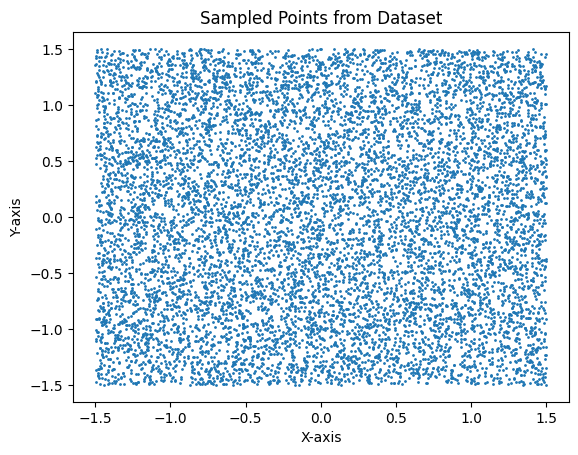

In [28]:
# see points sampled from the dataset
dataset = SampleDataset(
    coef=1.0,
    generator=generator,
    n_samples=int(1e4),
    batch_size=int(1e4),
    device='cpu',
    dtype=torch.float32
)
batch = next(iter(dataset))
plt.scatter(batch[0][:,0].numpy(), batch[0][:,1].numpy(), s=1)
plt.title("Sampled Points from Dataset")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

In [29]:
# peprare for training
model = NeuralNet().cuda()
training_ret = []

In [30]:
from phd_laboratory.neuralnet.templates import Scheduler

# training 1: pre-training: warmup
class MySchedule(torch.optim.lr_scheduler.LambdaLR, Scheduler):
    def __init__(self, optimizer: torch.optim.Optimizer, initial_lr: float, final_lr: float, n_epochs: int):
        super(MySchedule, self).__init__(
            optimizer,
            lr_lambda=lambda epoch: epoch * float(final_lr/initial_lr - 1) / float(n_epochs) + 1.0,
        )
    def sstep(self, metrics = None):
        super().step(metrics)

optimizer = torch.optim.AdamW(model.net.parameters(), lr=1e-5)
scheduler = MySchedule(optimizer, initial_lr=1e-5, final_lr=5e-4, n_epochs=100)

train_dataset = SampleDataset(0.0, generator, n_samples=int(32768), batch_size=256, device=torch.device('cpu'), dtype=torch.float32)
val_dataset = SampleDataset(1.0, generator, n_samples=int(2), batch_size=2, device=torch.device('cpu'), dtype=torch.float32)
train_loader = DataLoader(train_dataset, batch_size=None)
val_loader = DataLoader(val_dataset, batch_size=None)

training_ret.append(neuralnet.diagnostic(
    model,
    optimizer,
    n_epochs=100,
    dataloader=train_loader,
    device='cuda',
    closure=TrainLoss(),
    metrics_fn=neuralnet.Metrics(TrainLoss(), val_loader, device='cuda'),
    scheduler=scheduler,
))

Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/128 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/128 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/128 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/128 [00:00<?, ?it/s]

...

Training Batches:   0%|          | 0/128 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/128 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/128 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/128 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/128 [00:00<?, ?it/s]

In [31]:
backup_model = NeuralNet()
backup_model.load_state_dict(model.state_dict())
backup_training_ret = training_ret.copy()

In [32]:
# training 2: training: Reduce LROnPlateau
model.load_state_dict(backup_model.state_dict())
training_ret = backup_training_ret.copy()
class MySchedule(torch.optim.lr_scheduler.ReduceLROnPlateau, Scheduler):
    def __init__(self, optimizer: torch.optim.Optimizer):
        super(MySchedule, self).__init__(
            optimizer,
            mode='min',
            factor=0.5,
            patience=40,
            min_lr=2e-5,
        )

    def sstep(self, metrics = None):
        super(MySchedule, self).step(metrics['Lu'])

optimizer = torch.optim.AdamW(model.parameters(), lr=optimizer.param_groups[0]['lr'])
scheduler = MySchedule(optimizer)

train_dataset = SampleDataset(0.0, generator, n_samples=int(32768), batch_size=512, device=torch.device('cpu'), dtype=torch.float32)
val_dataset = SampleDataset(1.0, generator, n_samples=int(4096), batch_size=4096, device=torch.device('cpu'), dtype=torch.float32)
train_loader = DataLoader(train_dataset, batch_size=None)
val_loader = DataLoader(val_dataset, batch_size=None)

training_ret.append(neuralnet.diagnostic(
    model,
    optimizer,
    n_epochs=300,
    dataloader=train_loader,
    device='cuda',
    closure=TrainLoss(),
    metrics_fn=neuralnet.Metrics(TrainLoss(), val_loader, device='cuda'),
    scheduler=scheduler,
    schedule_with_metrics=True,
))

Training Progress:   0%|          | 0/300 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/64 [00:00<?, ?it/s]

...

Training Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/64 [00:00<?, ?it/s]

In [33]:
backup_model = NeuralNet()
backup_model.load_state_dict(model.state_dict())
backup_training_ret = training_ret.copy()

In [34]:
# training 3: fine tuning: SGD with momentum
#model.load_state_dict(backup_model.state_dict())
#training_ret = backup_training_ret.copy()
class MySchedule(torch.optim.lr_scheduler.LambdaLR, Scheduler):
    def __init__(self, optimizer: torch.optim.Optimizer, coef: float, start: float):
        super(MySchedule, self).__init__(optimizer, lr_lambda=lambda epoch: 1/(start+coef*epoch))
    def sstep(self, metrics = None):
        super().step(metrics)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-5, momentum=0.9, weight_decay=0.01)
# scheduler with O(1/epoch) decay
coef = 1.0  # little value implies slow decay
start = 1.0  # 1/start is the first value, high value implies slow decay
scheduler = MySchedule(optimizer, coef=coef, start=start)

train_dataset = SampleDataset(0.0, generator, n_samples=int(32768), batch_size=2048, device=torch.device('cpu'), dtype=torch.float32)
val_dataset = SampleDataset(1.0, generator, n_samples=int(2), batch_size=2, device=torch.device('cpu'), dtype=torch.float32)
train_loader = DataLoader(train_dataset, batch_size=None)
val_loader = DataLoader(val_dataset, batch_size=None)

training_ret.append(neuralnet.diagnostic(
    model,
    optimizer,
    n_epochs=50,
    dataloader=train_loader,
    device='cuda',
    closure=neuralnet.Closure(TrainLoss()),
    metrics_fn=neuralnet.Metrics(TrainLoss(), val_loader, device='cuda'),
    scheduler=scheduler,
))

Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/16 [00:00<?, ?it/s]

...

Training Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [35]:
backup_model = NeuralNet()
backup_model.load_state_dict(model.state_dict())
backup_training_ret = training_ret.copy()

In [36]:
# reload
model.load_state_dict(backup_model.state_dict())
training_ret = backup_training_ret.copy()
pass

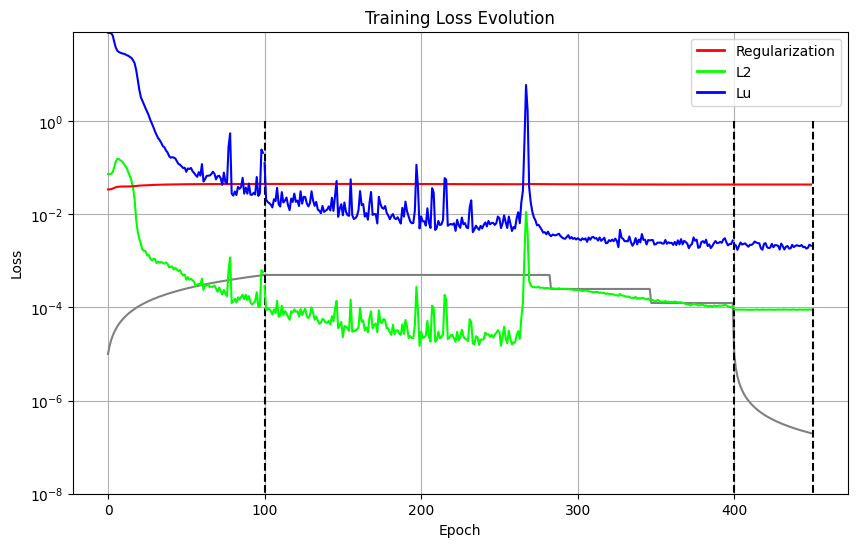

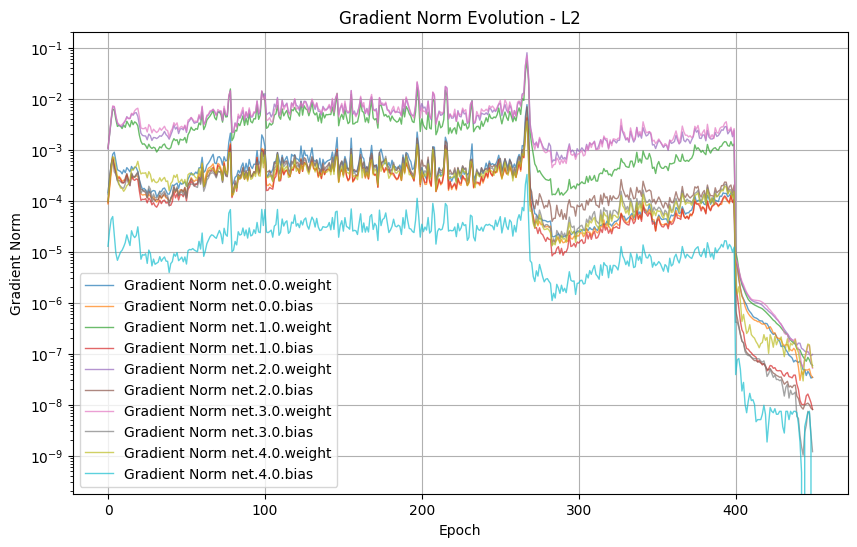

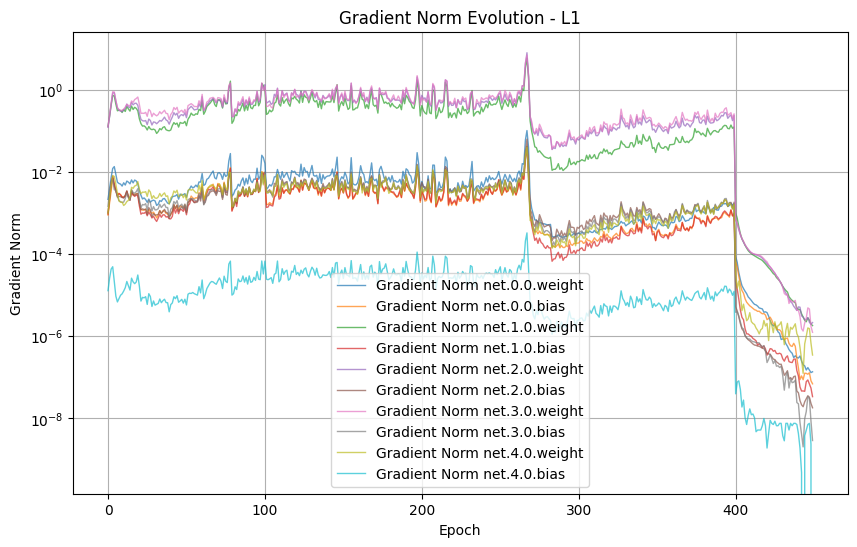

In [37]:
# validation
loss_history: list[dict[str, list[float]]] = []
for phase in range(len(training_ret)):
    current_phase: dict[str, list[float]] = {}
    for epoch in range(len(training_ret[phase]['train_loss_history'])):
        epoch_results = training_ret[phase]['train_loss_history'][epoch]
        reverse_dict = {}
        for batch in epoch_results:
            for name in batch.keys():
                if name not in reverse_dict:
                    reverse_dict[name] = []
                reverse_dict[name].append(batch[name])
        for name in reverse_dict.keys():
            avarage = sum(reverse_dict[name]) / len(reverse_dict[name])
            if name not in current_phase:
                current_phase[name] = []
            current_phase[name].append(avarage)
    loss_history.append(current_phase)
lr_history = [
    result['lr_history'][0] for result in training_ret
]
val_loss_history: list[dict[str, list[float]]] = []
for phase in range(len(training_ret)):
    current_phase: dict[str, list[float]] = {}
    for epoch in range(len(training_ret[phase]['val_loss_history'])):
        for name in training_ret[phase]['val_loss_history'][epoch].keys():
            if name not in current_phase:
                current_phase[name] = []
            current_phase[name].append(training_ret[phase]['val_loss_history'][epoch][name])
    val_loss_history.append(current_phase)
grad_norm_history: dict = {}
for phase in range(len(training_ret)):
    for epoch in range(len(training_ret[phase]['grad_norm_history'])):
        for name in training_ret[phase]['grad_norm_history'][epoch].keys():
            for norm_type in training_ret[phase]['grad_norm_history'][epoch][name].keys():
                avarage = training_ret[phase]['grad_norm_history'][epoch][name][norm_type]
                avarage = sum(avarage) / len(avarage)
                if norm_type not in grad_norm_history:
                    grad_norm_history[norm_type] = {}
                if name not in grad_norm_history[norm_type]:
                    grad_norm_history[norm_type][name] = []
                grad_norm_history[norm_type][name].append(avarage)

plt.figure(figsize=(10,6))
plt.plot(sum(lr_history, []), label="Learning Rate", color='gray')
# marge names from all phases
names = set()
for phase in range(len(loss_history)):
    names.update(loss_history[phase].keys())
# set a random color for each name
hsv_angle = torch.arange(len(names)).float() / len(names)  # evenly spaced angles in [0, 1)
# convert hsv to rgb
colors = np.array([hsv_to_rgb((h, 1.0, 1.0)) for h in hsv_angle])
map_names_colors = {name: tuple(colors[i]) for i, name in enumerate(names)}
# plot training losses
for phase in range(len(loss_history)):
    names = list(loss_history[phase].keys())
    for name in names:
        plt.plot(
            range(
                sum(len(loss_history[k][name]) for k in range(phase)),
                sum(len(loss_history[k][name]) for k in range(phase)) + len(loss_history[phase][name])
            ),
            loss_history[phase][name],
            color=map_names_colors[name],
        )
    # insert vline
    plt.vlines(sum(len(loss_history[k][name]) for k in range(phase)) + len(loss_history[phase][name]), ymin=0, ymax=1, colors="black", linestyles="--")
legend_elements = [
    Line2D([0], [0], color=map_names_colors[name], lw=2, label=name) for name in map_names_colors.keys()
]
# set minimum y value to 1e-8 for better visualization
plt.ylim(bottom=1e-8)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Evolution')
plt.legend(handles=legend_elements)
plt.grid()
plt.show()

# plot gradient norms
for norm_type in grad_norm_history.keys():
    plt.figure(figsize=(10,6))
    for name in grad_norm_history[norm_type].keys():
        plt.plot(
            grad_norm_history[norm_type][name],
            label=f'Gradient Norm {name}',
            alpha=0.7,
            linewidth=1
        )
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Gradient Norm')
    plt.title(f'Gradient Norm Evolution - {norm_type}')
    plt.legend()
    plt.grid()
    plt.show()

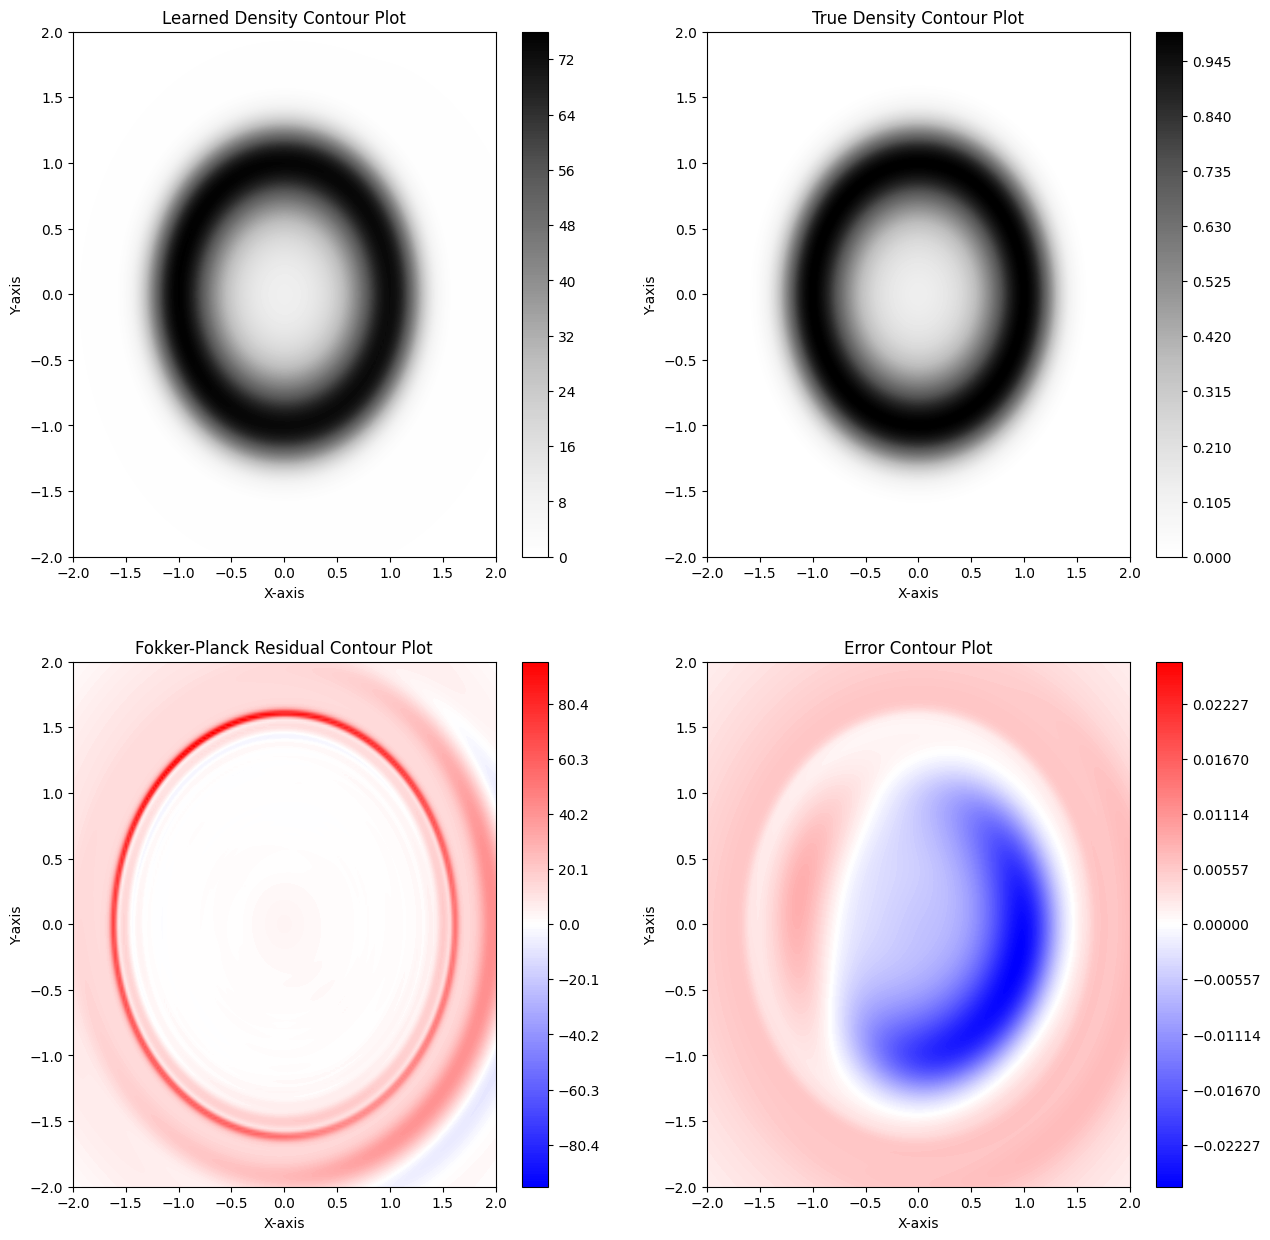

In [38]:
# visualization of the learned density
import numpy as np

model.eval()
model.to('cpu')

# get uniform grid points
grid_size = 200
x = torch.linspace(-2, 2, grid_size)
y = torch.linspace(-2, 2, grid_size)
X, Y = torch.meshgrid(x, y, indexing='ij')
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to('cpu')
with torch.no_grad():
    learned_density = model(grid_points).cpu().reshape((grid_size, grid_size))
    true_density = objective_density(grid_points.cpu()).reshape((grid_size, grid_size))
    true_density = true_density
plt.figure(figsize=(15, 15))
plt.subplot(2, 2, 1)
plt.contourf(X.numpy(), Y.numpy(), learned_density.numpy(), levels=grid_size, cmap='Greys', vmin=0)
plt.colorbar()
plt.title("Learned Density Contour Plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.subplot(2, 2, 2)
plt.contourf(X.numpy(), Y.numpy(), true_density.numpy(), levels=grid_size, cmap='Greys', vmin=0)
plt.colorbar()
plt.title("True Density Contour Plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
# plot Lu error
plt.subplot(2, 2, 3)
Lu: torch.Tensor = TrainLoss().FKmodel.u_t(lambda y,_: model(y), grid_points.to('cpu'), 0.0).cpu().reshape((grid_size, grid_size))
np_Lu = Lu.detach().numpy()
vmax = np.abs(np_Lu).max()
levels = np.linspace(-vmax, vmax, grid_size+1)
plt.contourf(X.numpy(), Y.numpy(), np_Lu, levels=levels, cmap='bwr', vmin=-vmax, vmax=vmax)
plt.colorbar()
plt.title("Fokker-Planck Residual Contour Plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
# plot error
plt.subplot(2, 2, 4)
error = learned_density/learned_density.sum()*true_density.sum() - true_density
np_error = error.detach().numpy()
vmax = np.abs(np_error).max()
levels = np.linspace(-vmax, vmax, grid_size+1)  # 100 intervals, odd number ensures zero level
plt.contourf(
    X.numpy(),
    Y.numpy(),
    error.detach().numpy(),
    levels=levels,
    cmap='bwr',
    vmin=-vmax,
    vmax=vmax
)
plt.colorbar()
plt.title("Error Contour Plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")

plt.show()

In [39]:
# testing the activity
from typing import Any


threshold = 1e-8
validation_dataset = SampleDataset(0.0, generator, n_samples=int(2048), batch_size=2048, device=torch.device('cpu'), dtype=torch.float32)
validation_loader = DataLoader(validation_dataset, batch_size=None)

with torch.no_grad():
    x = next(iter(validation_loader))[0].to('cpu')
    vars: dict[str, dict[str, Any]] = model.get_covariances(x)
    for layer_info in vars.values():
        eival: torch.Tensor = layer_info['eigenvalues']
        total_information: float = layer_info['trace']
        relative_threshold = threshold * layer_info['trace']
        cum_sum = torch.sort(eival).values.cumsum(dim=0)
        deadneurons = torch.count_nonzero(cum_sum < relative_threshold).item()
        print("Layer:", layer_info['layer_name'])
        print(f"total information {total_information}")
        print(f"dead neurons {deadneurons}")
        print(f"alive neurons {eival.numel()-deadneurons}")
        print(f"percentage of dead neurons {deadneurons/eival.numel()*100:.2f}%")
        print(f"min variance influence {eival.min().item()/total_information*100:.6f}%")
        print("-----")

Layer: layer_0_Sequential
total information 6.868890762329102
dead neurons 72
alive neurons 56
percentage of dead neurons 56.25%
min variance influence 0.000000%
-----
Layer: layer_1_Sequential
total information 9.286211967468262
dead neurons 70
alive neurons 58
percentage of dead neurons 54.69%
min variance influence 0.000000%
-----
Layer: layer_2_Sequential
total information 57.60035705566406
dead neurons 64
alive neurons 64
percentage of dead neurons 50.00%
min variance influence 0.000000%
-----
Layer: layer_3_Sequential
total information 448.850830078125
dead neurons 49
alive neurons 79
percentage of dead neurons 38.28%
min variance influence 0.000000%
-----
Layer: layer_4_Sequential
total information 614.3125610351562
dead neurons 0
alive neurons 1
percentage of dead neurons 0.00%
min variance influence 100.000000%
-----


## Deep Learning Problem

I have a generator of samples $X$ with distribution $\mathcal{F}$, but there isn't a target output.

About the desidered output I have only properties. For example:
- The output is a density, so I want $\tilde{u}_\theta\geq0$ and $\int_{R^n} dx \tilde{u}_\theta(x) = 1$
- The output is a steady state of the Fokker Planck equation.

These two properties define the desidered solution, and I introduce these properties in the loss function.

Formally, the neural network is defined as $\tilde{u}:\Omega\times\Theta\times\mathcal{D}\to\mathbb{R}$ where:
- $\Omega$ is the measurable space with probability measure $\mathbb{P}$.
- $\Theta$ is the space of parameters, we can assume it as a vector in $\mathbb{R}^P$ with $P$ number of parameters.
- $\mathcal{D}$ is the domain of the simulation.

I want that $\tilde{u}_\theta\approx u$ where $u$ is the target.

The loss function is defined as $\mathbb{E}_\omega\left[\varphi_u(\tilde{u}_\theta^\omega)\right]$ where $\varphi_u$ takes the realization of the stochastic model $\tilde{u}_\theta^\omega$ and returns real value. $\varphi_u$ has the following properties:
- $\varphi_u$ is a non-negative convex function
- $\varphi_u(u)=0$

This definition of the loss function is a generalization of famous loss functions: MSE (et simila), KL Divergence (or Maximum Likelihood) and Score Matching.

Using the Jensen inequality, I know that $\mathbb{E}_\omega\left[\varphi_u(\tilde{u}_\theta^\omega)\right] \geq \varphi_u(\mathbb{E}_\omega\left[\tilde{u}_\theta^\omega\right])$. So if I minimized $\mathbb{E}_\omega\left[\varphi_u(\tilde{u}_\theta^\omega)\right]$ then I wouldn't be minimizing $\varphi_u(\mathbb{E}_\omega\left[\tilde{u}_\theta^\omega\right])$, but I would be imposing (if I'm lucky) a good upper bound.

In this case I use:

$$
    \varphi_u(\tilde{u}_\theta^\omega) = \mathbb{E}_{X\sim u}\left[\left\|\mathcal{L}\tilde{u}_\theta^\omega(X)\right\|^2\right] + \lambda\left(\mathbb{E}_{X\sim u}\left[\tilde{u}_\theta^\omega(X)\right]-\mathbb{E}_{X\sim u}\left[u(X)\right]\right)^2
$$

The first loss uses the Fokker Planck model and the second one is a relaxation of the density condition, indeed I'm sure that $\tilde{u}_\theta^\omega$ is a density if $\mathcal{L}\tilde{u}_\theta^\omega(x)=0$ $\mathcal{Q}$-a.s.

The expectation value of the second loss $\mathbb{E}_{X\sim u}\left[u(X)\right]=\int dx u(x)^2$ can be computed numerically.

For a toy experiment I use the second loss $\left(\mathbb{E}_{X\sim u}\left[\tilde{u}_\theta^\omega(X)\right]-1\right)^2$, in this way $\tilde{u}_\theta^\omega\neq0$

## Deep Learning

The neural network is denoted by $\tilde{u}_\theta$ where $\theta$ is the set of parameters of the neural network.

The neural network tries to solve: $\mathcal{L}\tilde{u}_\theta(x)=0$, but the trivial solution is $\tilde{u}_\theta\approx0$. For this reason I impose $\int \tilde{u}_\theta(x)dx=1$

### Loss Function

To solve the scale problem I use the loss function $\mathbb{E}_{x\sim Q}\left[\left(\tilde{u}_\theta-1\right)^2\right]$, moreover it controls the squared bias: $\mathbb{E}_{x\sim Q}\left[\tilde{u}_\theta-1\right]^2\leq\mathbb{E}_{x\sim Q}\left[\left(\tilde{u}_\theta-1\right)^2\right]$

The final loss function is: $\mathbb{E}_{x\sim Q}\left[\left(\mathcal{L}\tilde{u}_\theta(x)\right)^2\right]+\lambda\mathbb{E}_{x\sim Q}\left[\left(\tilde{u}_\theta(x)-1\right)^2\right]$

The distribution $Q$ is a mixture of Uniform distribution and $u$ distribution. The data loader uses a random variable $b\sim B(p)$, if $b=1$ then I have a data point $x\sim u$ if $b=0$ then I have a data point $x\sim\text{Unif}\left[\mathcal{D}\right]$.

The training uses an approximation of the loss via Monte Carlo:
$$
    L = \frac{1}{N_X}\sum_{i=1}^{N_X}\left(\mathcal{L}\tilde{u}_\theta(x_i)\right)^2 + \lambda\frac{1}{N_Y}\sum_{j=1}^{N_Y} \left(\tilde{u}_\theta(y_j)-1\right)^2
$$
where $x_1,\ldots,x_{N_X}\sim Q$ i.i.d. and $y_1,\ldots,y_{N_Y}\sim Q$ i.i.d

Special training parameters:
- $N_X+N_Y$ is the size of the batch.
- $\alpha=\frac{N_X}{N_Y}$ is the proportion between the two loss.

### Annotation
Una rete con attivazioni tanh con loss 

## Coordinate Invariant Loss

In this case I have a generator of data points with unknown distribution $\mathcal{F}$ so I can define a loss function as $\varphi_u(\tilde{u}_\theta^\omega) = \mathbb{E}_{X\sim u}\left[\gamma\left(u\middle\|\tilde{u}_\theta^\omega\right)(X)\right]$ with these properties:
- **coordinate-invariant property**: $\gamma\left(\left|J_h^{-1}\right|u\circ h\middle\|\left|J_h^{-1}\right|\tilde{u}_\theta^\omega\circ h\right)\equiv\gamma\left(u\middle\|\tilde{u}_\theta^\omega\right)\circ h$ for all differentiable bijective functions $h:\mathbb{R}^n\to\mathbb{R}^n$
- **convexity**: $f\mapsto\gamma\left(u\middle\|f\right)$ is a convex function so: $\gamma\left(u\middle\|tf+(1-t)g\right)\leq t\gamma\left(u\middle\|f\right)+(1-t)\gamma\left(u\middle\|g\right)$
- **minimum**: $u$ is the minimum of $f\mapsto\gamma\left(u\middle\|f\right)$ and $\gamma\left(u\middle\|u\right)\equiv0$

In this way the loss is **coordinate-invariant**. In other terms, $\varphi_u(\tilde{u}_\theta^\omega)=\varphi_{u_h}(\tilde{u_h}_\theta^\omega)$ where $h$ is a differentiable bijective function. Indeed:
$$
    \varphi_{u_h}(\tilde{u_h}_\theta^\omega) = \int dx u(h(x))\left|J_h^{-1}(x)\right|\gamma\left(\xi\mapsto u(h(\xi))\left|J_h^{-1}(\xi)\right|\middle\|\xi\mapsto \tilde{u}_\theta^\omega(h(x))\left|J_h^{-1}(\xi)\right|\right)(x) = \int dx u(h(x))\left|J_h^{-1}(x)\right|\gamma\left(u\middle\|\tilde{u}_\theta^\omega\right)(h(x)) = \int dy u(y)\gamma\left(u\middle\|\tilde{u}_\theta^\omega\right)(y) = \varphi_{u}(\tilde{u}_\theta^\omega)
$$

### Just an example

I want define a loss $\mathbb{E}_\omega\left[\mathbb{E}_{X\sim u}\left[\gamma\left(u\middle\|\tilde{u}_\theta^\omega\right)(X)\right]\right]$ such that:
- $\gamma\left(\left|J_h^{-1}\right|u\circ h\middle\|\left|J_h^{-1}\right|\tilde{u}_\theta^\omega\circ h\right)\equiv\gamma\left(u\middle\|\tilde{u}_\theta^\omega\right)\circ h$ for all differentiable bijective functions $h:\mathbb{R}^n\to\mathbb{R}^n$
- $f\mapsto\gamma\left(u\middle\|f\right)$ is a convex function so: $\gamma\left(u\middle\|tf+(1-t)g\right)\leq t\gamma\left(u\middle\|f\right)+(1-t)\gamma\left(u\middle\|g\right)$
- $u$ is the minimum of $f\mapsto\gamma\left(u\middle\|f\right)$ and $\gamma\left(u\middle\|u\right)\equiv0$

The idea is insert $u$ in $\gamma$ but using the properties of $u$. For example:

$$
    \gamma\left(u\middle\|f\right) = \left|\frac{\left\|f\right\|_{L^1}}{\left\|u\right\|_{L^1}}-1\right|
$$

I know that $u$ is a density so also if I don't know the exact formulation of $u$ I can use it in the loss function.

### Implementation

In this implementation I use a common loss function: $\mathbb{E}_{X\sim\mathcal{L}}\left[\left\|\mathcal{L}\tilde{u}_\theta^\omega(X)\right\| \right]$